**NOTE: THIS NOTEBOOK WAS RUN USING GOOGLE COLAB ON A T4 GPU**

**THE COMBINATION GRADIENT BOOSTING + VGG-16 NEEDS TO BE RUN ON A T1 GPU INSTEAD DUE TO MORE MEMORY USAGE FOR SHAP**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%pip install optuna timm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 103.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 623.9/623.9 kB 49.0 MB/s eta 0:00:00


In [ ]:
%pip install imblearn shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 498.0/498.0 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.1/236.1 kB 23.5 MB/s eta 0:00:00


## Importing packages

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import optuna
from optuna.trial import TrialState
import os
from pathlib import Path
import pandas as pd
import pickle
import torch
import torch.nn as nn
import time
import psutil
import numpy as np
import seaborn as sns
import gc
import timm
import shap
import joblib
from timm.models.vision_transformer import VisionTransformer
from timm.layers import resample_abs_pos_embed
from PIL import Image
from torch.utils.data import DataLoader
from torchvision import models
from torchvision import transforms
from torchvision.transforms import v2 # Use torchvision.transforms if v2 isn't installed
from torchvision.transforms import InterpolationMode
from torchvision.models.swin_transformer import SwinTransformer
from torch.utils.data import Dataset
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import RandomOverSampler

In [ ]:
# Utility function to print out memory (RAM) and processing (CPU) usage
def log_resource_usage(stage_name=""):
    process = psutil.Process(os.getpid())

    # RAM usage in Megabytes
    ram_usage_mb = process.memory_info().rss / (1024 * 1024)

    # CPU usage percentage (interval calculates usage over 0.1 seconds)
    cpu_usage_pct = psutil.cpu_percent(interval=1)

    print(f"--- [Resource Log: {stage_name}] ---")
    print(f"RAM Usage: {ram_usage_mb:.2f} MB")
    print(f"System CPU Usage: {cpu_usage_pct}%")
    print("-" * 35)

In [ ]:
!unzip -q "/content/drive/MyDrive/ICS5200 Files Final.zip" "data/*" "dataset_final/*" -d "/content/"

## Early Stopping

In [ ]:
os.makedirs('outputs/plots', exist_ok=True)
os.makedirs('outputs/models', exist_ok=True)

In [ ]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0, checkpoint_path="outputs/models/cnn_resnet18.pth"):
        self.patience = patience
        self.min_delta = min_delta
        self.checkpoint_path = checkpoint_path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0  # Reset counter since we found a better model

    def save_checkpoint(self, model):
        """Saves model when validation loss decreases."""
        torch.save(model.state_dict(), self.checkpoint_path)
        print(f"--> Validation loss decreased. Saving best model model configuration...")

## image_loader (from utils/image_loader.py)

In [ ]:
class WebpageScreenshotDataset(Dataset):
    def __init__(self, df, image_col="screenshot_path", label_col="accessibility_label", transform=None):
        self.df = df.reset_index(drop=True)
        self.image_col = image_col
        self.label_col = label_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_path = self.df.loc[idx, self.image_col]
        label = int(self.df.loc[idx, self.label_col])

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

IMG_SIZE = (320, 704)

# Perform transformations on the images to prep them for use in models (both training and inference)
def get_image_transforms(image_size=IMG_SIZE, is_train=False):
    structural_transforms = [
        v2.Resize(image_size, interpolation=InterpolationMode.BICUBIC),
    ]

    normalization_transforms = [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ]
    if is_train:
        return v2.Compose([
            *structural_transforms,
            # Simulate different screen brightness/contrast profiles
            v2.ColorJitter(
                brightness=0.1,
                contrast=0.1,
                saturation=0.0,              # Keep colors intact if color matters for your classes
                hue=0.0
            ),
            *normalization_transforms
        ])
    else:
        # Testing pipeline remains strictly clean and deterministic
        return v2.Compose([
            *structural_transforms,
            *normalization_transforms
        ])


## data_loader (from utils/data_loader.py)

In [ ]:
FEATURES_FOR_SCORING = [
    # Screenshot-based visual features
    "edge_density",
    "contrast",
    "colour_variance",
    # "layout_density",
    "text_density_proxy",
    "brightness_variance",
    "whitespace_ratio",

    # DOM and content features
    "dom_depth",
    "num_links",
    "num_images",
    "num_buttons",
    "num_forms",
    "num_paragraphs",
    "num_headings",
    "word_count",

    # Advertisement and embedded-content features
    "num_advertisement_iframes",
    "num_non_ad_iframes",

    # ARIA and accessible-naming features
    "num_aria_attributes",
    "aria_attribute_density",
    "num_aria_label",
    "num_aria_labelledby",
    "num_aria_hidden",
    "num_aria_live",
    # "interactive_elements_without_label",

    # Image accessibility features
    "num_images_without_alt",
    "alt_text_coverage",

    # Heading accessibility features
    "heading_level_skips",
    "empty_heading_count",

    # Semantic landmark features
    "has_main_landmark",
    "has_nav_landmark",
    "semantic_element_ratio",

    # Accessible-name and form features
    # "buttons_without_accessible_name",
    # "links_without_accessible_name",
    # "inputs_without_label",
    "unlabelled_button_ratio",
    "unlabelled_link_ratio",
    "unlabelled_input_ratio",

    # Readability feature
    "average_paragraph_word_count",
]

NON_FEATURE_COLUMNS = [
    "id",
    "website",
    "page_type",
    "url",
    "screenshot_path",
    "html_path",
    "num_iframes",
    "accessibility_label",
    "accessibility_label_text",
    "advertisement_iframes",
    "accessibility_risk_score"
]

TARGET_COLUMN = "accessibility_label"


def load_dataset(dataset_path="data/final_dataset.csv"):
    df = pd.read_csv(dataset_path)

    missing_features = [
        feature
        for feature in FEATURES_FOR_SCORING
        if feature not in df.columns
    ]

    if missing_features:
        raise ValueError(
            "The dataset is missing required assessed features: "
            f"{missing_features}"
        )

    if TARGET_COLUMN not in df.columns:
        raise ValueError(
            f"The target column '{TARGET_COLUMN}' is missing from the dataset."
        )

    feature_columns = [col for col in FEATURES_FOR_SCORING]

    X = df[FEATURES_FOR_SCORING]
    y = df[TARGET_COLUMN]

    # Ensure every model input is numeric.
    for feature in FEATURES_FOR_SCORING:
        X[feature] = pd.to_numeric(X[feature], errors="coerce")

    return X, y, feature_columns


def split_and_scale_data(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

## evaluation (from utils/evaluation.py)

In [ ]:
def evaluate_model(model_name, y_test, predictions):
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, average="weighted", zero_division=0)
    recall = recall_score(y_test, predictions, average="weighted", zero_division=0)
    f1 = f1_score(y_test, predictions, average="weighted", zero_division=0)

    print(f"\n{model_name} Results")
    print("-" * 30)
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-Score :", f1)

    print("\nClassification Report")
    print(classification_report(y_test, predictions))

    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }


def save_feature_importance(model, feature_columns, output_path=None):
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    feature_importance_df = pd.DataFrame({
        "feature": feature_columns,
        "importance": model.feature_importances_
    })

    feature_importance_df = feature_importance_df.sort_values(
        by="importance",
        ascending=False
    )

    if output_path:
        if not os.path.exists(output_path):
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
        feature_importance_df.to_csv(output_path, index=False)

    print("\nTop 10 Features")
    print(feature_importance_df.head(10))

    return feature_importance_df


def save_classification_report(y_test, predictions, output_path=None):
    report_dict = classification_report(y_test, predictions, output_dict=True)

    # 2. Convert to DataFrame and transpose so classes are rows
    report_df = pd.DataFrame(report_dict).transpose()

    if output_path:
        if not os.path.exists(output_path):
            os.makedirs(os.path.dirname(output_path), exist_ok=True)

        with open(output_path, "w") as f:
            report_df.to_csv(output_path, index=True)

    print("\nClassification Report Saved successfully!")
    print(report_df) # Optional: print to console


def plot_confusion_matrix(model_name, y_test, predictions, output_path=None):
    matrix = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(6, 5))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues")

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()

    if output_path:
        if not os.path.exists(output_path):
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
        plt.savefig(output_path, dpi=300)

    plt.show()

def generate_global_shap_plots(model, X_test, feature_columns, model_name, output_dir="outputs/plots_shap"):
    os.makedirs(output_dir, exist_ok=True)

    # Unwrap pipeline classifier if present
    if hasattr(model, "named_steps") and "classifier" in model.named_steps:
        base_estimator = model.named_steps["classifier"]
    else:
        base_estimator = model

    X_test_df = pd.DataFrame(X_test, columns=feature_columns)

    # Gradient Boosting Multiclass Fix: TreeExplainer doesn't support 3+ classes for Sklearn GB
    if "GradientBoosting" in type(base_estimator).__name__:
        X_background = shap.kmeans(X_test_df, 50).data
        explainer = shap.KernelExplainer(base_estimator.predict_proba, X_background)

        raw_shap_values = explainer.shap_values(
            X_test_df,
            nsamples=2 * len(feature_columns) + 1
        )

        if isinstance(raw_shap_values, list):
            vals = np.stack(raw_shap_values, axis=-1)
        else:
            vals = raw_shap_values

        expected_value = explainer.expected_value
        if expected_value is None:
            expected_value = base_estimator.predict_proba(X_background).mean(axis=0)

        base_vals = np.array(expected_value) if isinstance(expected_value, list) else np.asarray(expected_value)

        # Broadcast to (n_samples, n_classes) so it matches vals' shape (samples, features, classes)
        n_samples = vals.shape[0]
        n_classes = vals.shape[-1]
        if base_vals.ndim == 1 and base_vals.shape[0] == n_classes:
            base_vals = np.tile(base_vals, (n_samples, 1))

        shap_values = shap.Explanation(
            values=vals,
            base_values=base_vals,
            data=X_test_df.values,
            feature_names=list(feature_columns)
        )
    else:
        # Fast path for Random Forest and standard models
        explainer = shap.TreeExplainer(base_estimator)
        shap_values = explainer(X_test_df, check_additivity=False)
    # explainer = shap.TreeExplainer(base_estimator)
    # shap_values = explainer(X_test_df, check_additivity=False)

    # Extract raw numpy values from the Explanation object
    vals = shap_values.values if hasattr(shap_values, "values") else shap_values

    # Average mean absolute impact across samples (and classes if multiclass)
    if vals.ndim == 3:
        mean_abs_shap = np.abs(vals).mean(axis=(0, 2))
    else:
        mean_abs_shap = np.abs(vals).mean(axis=0)

    shap_df = pd.DataFrame(
        mean_abs_shap,
        index=feature_columns,
        columns=["Mean |SHAP|"]
    ).sort_values("Mean |SHAP|", ascending=False)

    print("Top Global Features:")
    print(shap_df.head(15))

    # Plot & Save Global Summary Plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_df, feature_names=feature_columns, show=False)
    ax = plt.gca()

    row_totals = {}
    for p in ax.patches:
        width = p.get_width()
        if width > 0.015:  # Only annotate segments wide enough to be readable
            x_center = p.get_x() + width / 2
            y_center = p.get_y() + p.get_height() / 2

            # Add subtotal inside the specific class sub-bar segment
            ax.text(
                x_center,
                y_center,
                f"{width:.3f}",
                va='center',
                ha='center',
                fontsize=7.5,
                color='white',
                weight='bold'
            )

        # Track total bar length per feature row
        y = p.get_y()
        row_totals[y] = row_totals.get(y, 0) + width

    # Add the overall sum at the end of each stacked bar
    for y, total_val in row_totals.items():
        if total_val > 0:
            ax.text(
                total_val + 0.002,
                y + 0.25,
                f"Total: {total_val:.3f}",
                va='center',
                ha='left',
                fontsize=8.5,
                color='black',
                weight='bold'
            )

    # Extend x-axis limit slightly so labels don't get clipped
    max_x = max(row_totals.values()) if row_totals else 0.15
    ax.set_xlim(0, max_x * 1.15)

    legend = ax.get_legend()
    if legend is not None:
        for text_obj, new_label in zip(legend.get_texts(), ["High", "Medium", "Low"]):
            text_obj.set_text(new_label)

    plt.title(f"{model_name} Global SHAP Feature Importance", fontsize=14, pad=15)
    plt.xlabel("SHAP value (Impact on Model Output)")
    plt.tight_layout()

    file_name = f"{model_name.lower().replace(' ', '_')}_shap_summary.png"
    save_path = os.path.join(output_dir, file_name)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"SHAP summary plot successfully saved to: {save_path}")

    return shap_values

def generate_per_class_beeswarm(shap_values, X_test_df, feature_columns, model_name, class_names=None, top_n=10, output_dir="outputs/plots_shap"):
    os.makedirs(output_dir, exist_ok=True)

    vals = shap_values.values if hasattr(shap_values, "values") else shap_values

    if vals.ndim != 3:
        print("Model output is not multiclass (values.ndim != 3) — a standard "
              "shap.summary_plot beeswarm already shows this; skipping per-class breakdown.")
        return

    n_samples, n_features, n_classes = vals.shape

    if class_names is None:
        class_names = [f"Class {i}" for i in range(n_classes)]

    # Rank features by overall mean |SHAP| (same ranking as your stacked bar)
    mean_abs_shap = np.abs(vals).mean(axis=(0, 2))
    top_idx = np.argsort(mean_abs_shap)[::-1][:top_n]
    top_features = [feature_columns[i] for i in top_idx]

    X_top = X_test_df[top_features]

    fig, axes = plt.subplots(1, n_classes, figsize=(6 * n_classes, 6), sharex=False)
    if n_classes == 1:
        axes = [axes]

    for c in range(n_classes):
        # Build a 2D Explanation for this class, restricted to the top features
        class_vals = vals[:, top_idx, c]

        class_base = shap_values.base_values
        if hasattr(class_base, "ndim") and class_base.ndim == 2:
            class_base = class_base[:, c]
        elif hasattr(class_base, "ndim") and class_base.ndim == 1 and class_base.shape[0] == n_classes:
            class_base = np.full(n_samples, class_base[c])

        class_exp = shap.Explanation(
            values=class_vals,
            base_values=class_base,
            data=X_top.values,
            feature_names=top_features
        )

        plt.sca(axes[c])
        shap.summary_plot(class_exp, X_top, show=False, plot_size=None)
        axes[c].set_title(f"{model_name} — {class_names[c]}", fontsize=12)

    plt.tight_layout()
    file_name = f"{model_name.lower().replace(' ', '_')}_shap_beeswarm_per_class.png"
    save_path = os.path.join(output_dir, file_name)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Per-class beeswarm plot saved to: {save_path}")
    return top_features


def generate_shap_error_plots(model, X_test, y_test, y_pred, feature_columns, model_name, shap_values, output_dir="outputs/plots_shap"):
    os.makedirs(output_dir, exist_ok=True)

    X_test_df = pd.DataFrame(X_test, columns=feature_columns)

    misclassified_idx = np.where(y_pred != y_test)[0]

    # Inspect SHAP values strictly for misclassified instances to diagnose failure modes
    misclassified_shap = shap_values[misclassified_idx]

    # Ensure misclassified_shap is extracted as a NumPy array
    raw_misclassified = misclassified_shap.values if hasattr(misclassified_shap, "values") else misclassified_shap

    # Handle shape based on binary (2D) vs multiclass (3D) SHAP output
    if raw_misclassified.ndim == 3:
        # Shape: (samples, features, classes) -> average across samples (axis 0) & classes (axis 2)
        mean_error_shap = np.abs(raw_misclassified).mean(axis=(0, 2))
    else:
        # Shape: (samples, features) -> average across samples (axis 0)
        mean_error_shap = np.abs(raw_misclassified).mean(axis=0)

    misclassified_shap_df = pd.DataFrame({
        'Feature': X_test_df.columns,
        'Mean_Abs_SHAP_Error': mean_error_shap
    }).sort_values(by='Mean_Abs_SHAP_Error', ascending=False)

    print("Top Global Features:")
    print(misclassified_shap_df.head(15))

    # Plot & Save Global Summary Plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_df, feature_names=feature_columns, show=False)
    ax = plt.gca()

    row_totals = {}
    for p in ax.patches:
        width = p.get_width()
        if width > 0.015:  # Only annotate segments wide enough to be readable
            x_center = p.get_x() + width / 2
            y_center = p.get_y() + p.get_height() / 2

            # Add subtotal inside the specific class sub-bar segment
            ax.text(
                x_center,
                y_center,
                f"{width:.3f}",
                va='center',
                ha='center',
                fontsize=7.5,
                color='white',
                weight='bold'
            )

        # Track total bar length per feature row
        y = p.get_y()
        row_totals[y] = row_totals.get(y, 0) + width

    # Add the overall sum at the end of each stacked bar
    for y, total_val in row_totals.items():
        if total_val > 0:
            ax.text(
                total_val + 0.002,
                y + 0.25,
                f"Total: {total_val:.3f}",
                va='center',
                ha='left',
                fontsize=8.5,
                color='black',
                weight='bold'
            )

    # Extend x-axis limit slightly so labels don't get clipped
    max_x = max(row_totals.values()) if row_totals else 0.15
    ax.set_xlim(0, max_x * 1.15)

    legend = ax.get_legend()
    if legend is not None:
        for text_obj, new_label in zip(legend.get_texts(), ["High", "Medium", "Low"]):
            text_obj.set_text(new_label)

    plt.title(f"{model_name} Global SHAP Feature Importance", fontsize=14, pad=15)
    # plt.xlabel("SHAP value (Impact on Model Output)")
    plt.tight_layout()

    file_name = f"{model_name.lower().replace(' ', '_')}_shap_error_summary.png"
    save_path = os.path.join(output_dir, file_name)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"SHAP error summary plot successfully saved to: {save_path}")


def compare_global_vs_error_shap(shap_values, X_test, y_test, y_pred, feature_columns, output_path=None):
    raw_shap = shap_values.values if hasattr(shap_values, "values") else shap_values
    mis_idx = np.where(y_pred != y_test)[0]

    # 1. Global Mean Absolute Impact
    global_impact = np.abs(raw_shap).mean(axis=(0, 2)) if raw_shap.ndim == 3 else np.abs(raw_shap).mean(axis=0)

    # 2. Error Mean Absolute Impact
    raw_mis = raw_shap[mis_idx]
    error_impact = np.abs(raw_mis).mean(axis=(0, 2)) if raw_mis.ndim == 3 else np.abs(raw_mis).mean(axis=0)

    # X_test_df = pd.DataFrame(X_test, columns=feature_columns)

    if feature_columns is not None:
        features = feature_columns
    elif hasattr(X_test, "columns"):
        features = X_test.columns
    else:
        features = [f"F_{i}" for i in range(raw_shap.shape[1])]

    df = pd.DataFrame({
        'Feature': features,
        'Global_Impact': global_impact,
        'Error_Impact': error_impact
    })

    # Calculate Ranks and Shifts
    df['Global_Rank'] = df['Global_Impact'].rank(ascending=False).astype(int)
    df['Error_Rank'] = df['Error_Impact'].rank(ascending=False).astype(int)
    df['Rank_Shift'] = df['Global_Rank'] - df['Error_Rank'] # Positive = higher priority in errors

    final_df = df.sort_values(by='Error_Rank')

    # with open(output_path, "w") as f:
    final_df.to_csv(output_path, index=True)

## CNN Training

In [ ]:
# Builds the ResNet-18 CNN model
def build_resnet18(num_classes, dropout=0.0):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    in_features = model.fc.in_features
    if dropout > 0.0:
        # Reconstruct the fc layer to include Dropout
        model.fc = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )
    else:
        model.fc = nn.Linear(in_features, num_classes)
    # model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

# Builds the ResNet-50 CNN model
def build_resnet50(num_classes, dropout=0.0):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    in_features = model.fc.in_features

    if dropout > 0.0:
        model.fc = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )
    else:
        model.fc = nn.Linear(in_features, num_classes)
    return model

# Builds the VGG-16 CNN model
def build_vgg16(num_classes, dropout=0.0):
    model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
    in_features = model.classifier[6].in_features
    if dropout > 0.0:
        model.classifier[6] = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )
    else:
        model.classifier[6] = nn.Linear(in_features, num_classes)
    return model

# Initialises any transformations on the train and test sets to be used within the CNN models
def cnn_init_transform(image_size=IMG_SIZE):
    train_transform = get_image_transforms(image_size, is_train=True)
    test_transform = get_image_transforms(image_size, is_train=False)

    return train_transform, test_transform

# Initialises the train and test sets for use within the CNN models
def cnn_init_dataset(train_df, test_df, train_transform, test_transform):
    train_dataset = WebpageScreenshotDataset(train_df, transform=train_transform)
    test_dataset = WebpageScreenshotDataset(test_df, transform=test_transform)

    return train_dataset, test_dataset

# Initalises the train and test loaders for use within the CNN models
def cnn_init_loader(train_dataset, test_dataset, batch_size=16):
    colab_workers = os.cpu_count()
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=colab_workers, pin_memory=True, persistent_workers=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=colab_workers, pin_memory=True, persistent_workers=True)

    return train_loader, test_loader

# Uses Optuna to optimise the hyperparameters of the CNN models
def tune_cnn(train_dt, test_dt, num_classes, n_trials=5):
    def objective(trial):
        lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
        # batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
        batch_size = trial.suggest_categorical("batch_size", [8, 16])
        optimizer = trial.suggest_categorical("optimizer", ["Adam", "AdamW", "SGD"])
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
        dropout = trial.suggest_float("dropout", 0.0, 0.5, step=0.1)

        max_epochs = 5 

        train_loader, test_loader = cnn_init_loader(train_dt, test_dt, batch_size=batch_size)

        print(f"\n--- Starting CNN Trial {trial.number} | lr: {lr:.6f}, batch_size: {batch_size}, optimizer: {optimizer}, weight_decay: {weight_decay}, dropout: {dropout} ---")

        try:
            unique_checkpoint = f"cnn_trial_{trial.number}"

            # We call the training loop using a temporary checkpoint path
            _, history, _ = train_cnn_model(
                train_loader=train_loader,
                test_loader=test_loader,
                num_classes=num_classes,
                epochs=max_epochs,
                batch_size=batch_size,
                lr=lr,
                optimizer=optimizer,
                weight_decay=weight_decay,
                dropout=dropout,
                checkpoint_name=unique_checkpoint,
                trial=trial
            )
            return max(history["test_acc"])
        except optuna.exceptions.TrialPruned:
            # If the inner function raised a Pruned exception, pass it up to Optuna
            raise
        except RuntimeError as e:
            if "CUDA out of memory" in str(e):
                print(f"Trial {trial.number} failed due to CUDA OOM. Skipping...")
                torch.cuda.empty_cache()
                return 0.0
            raise e
    
    # Creates and initalises the optimisation process
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.RandomSampler())
    study.optimize(objective, n_trials=n_trials)

    # Analyse the performance of all trials
    trials = study.trials

    completed_trials = [t for t in trials if t.state == TrialState.COMPLETE]
    pruned_trials = [t for t in trials if t.state == TrialState.PRUNED]
    failed_trials = [t for t in trials if t.state == TrialState.FAIL]

    print("--- Optuna Study Summary ---")
    print(f"Total Trials: {len(trials)}")
    print(f"Successfully Completed Trials: {len(completed_trials)}")
    print(f"Pruned (Stopped Early) Trials: {len(pruned_trials)}")
    print(f"Failed (Crashed) Trials: {len(failed_trials)}")

    # Display the results of the best performing trial
    if study.best_trial:
        print("\n--- Best Trial Results ---")
        print(f"  Trial Number: {study.best_trial.number}")
        print(f"  Best Accuracy: {study.best_trial.value:.4f}")
        print("  Best Hyperparameters:")
        for key, value in study.best_trial.params.items():
            print(f"    {key}: {value}")

    return study.best_params

# Main function which trains the selected CNN model
def train_cnn_model(train_loader, test_loader, num_classes=3, epochs=20, batch_size=16, lr=1e-4, optimizer="Adam", weight_decay=0.001, dropout=0.0, checkpoint_name=None, trial=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # model = build_resnet18(num_classes, dropout=dropout).to(device)   --- UNCOMMENT THIS TO RUN A RESNET-18 MODEL
    # model = build_resnet50(num_classes, dropout=dropout).to(device)   --- UNCOMMENT THIS TO RUN A RESNET-50 MODEL
    model = build_vgg16(num_classes, dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer == "AdamW":
        optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer == "SGD":
        optimiser = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        optimiser = torch.optim.Adam(model.parameters(), lr=lr)

    scaler = torch.amp.GradScaler("cuda" if device.type == "cuda" else "cpu")

    if checkpoint_name:
        checkpoint_file = f"outputs/models/{checkpoint_name}.pth"
    else:
        checkpoint_file = "outputs/models/cnn_resnet18_best_.pth"

    os.makedirs(os.path.dirname(checkpoint_file), exist_ok=True)
    early_stopping = EarlyStopping(patience=3, checkpoint_path=checkpoint_file)

    # Initialise parameters to track training performance over time
    history = {"train_loss": [], "test_loss": [], "test_acc": []}
    best_checkpoint_acc = 0.0

    # Trains the model given a number of epochs
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimiser.zero_grad()

            with torch.amp.autocast(device_type=device.type):
                outputs = model(images)
                loss = criterion(outputs, labels)

            # NEW: Scale loss, perform backward pass, and update weights using scaler
            scaler.scale(loss).backward() # Correctly scale and then call backward
            scaler.step(optimiser)        # Unscale gradients and apply optimizer step
            scaler.update()               # Update the scaler for the next iteration

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        # Evaluation Phase
        model.eval()
        total_test_loss = 0
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                with torch.amp.autocast(device_type=device.type):
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                total_test_loss += loss.item()
                predictions = torch.argmax(outputs, dim=1)
                total += labels.size(0)
                correct += (predictions == labels).sum().item()

        avg_test_loss = total_test_loss / len(test_loader)
        accuracy = correct / total

        # Update the history parameters with the appropriate values
        history["train_loss"].append(avg_train_loss)
        history["test_loss"].append(avg_test_loss)
        history["test_acc"].append(accuracy)

        # Display the performance results per epoch
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | Accuracy: {accuracy:.4f}")

        # Trigger early stopping if a decrease in accuracy performance in detected
        early_stopping(avg_test_loss, model)

        if early_stopping.best_loss == avg_test_loss:
            best_checkpoint_acc = accuracy

        if early_stopping.early_stop:
            print(f"Early stopping triggered! Training stopped at epoch {epoch+1}.")
            break

        if trial is not None:
            # Report intermediate result to Optuna
            trial.report(accuracy, epoch)

            # Check if Optuna thinks this trial should be terminated early
            if trial.should_prune():
                print(f"Trial {trial.number} pruned early at epoch {epoch} due to poor performance.")
                # Force clean up before raising the exception
                del model, optimizer
                gc.collect()
                torch.cuda.empty_cache()

                # Raise the explicit exception Optuna uses to catch a pruned trial
                raise optuna.exceptions.TrialPruned()

    print("Loading best model weights from checkpoint...")
    model.load_state_dict(torch.load(checkpoint_file))

    if checkpoint_name and os.path.exists(checkpoint_file):
        os.remove(checkpoint_file)

    return model, history, best_checkpoint_acc


def plot_cnn_loss_graph(history):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # Plot 1: Training & Test Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history["train_loss"], label="Train Loss", color="blue", marker="o")
    plt.plot(epochs_range, history["test_loss"], label="Test Loss", color="red", marker="o")
    plt.title("Training and Test Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # Plot 2: Test Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history["test_acc"], label="Test Accuracy", color="green", marker="s")
    plt.title("Test Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()

    # Optional: Save the plot as an image
    plt.savefig("outputs/plots/cnn_training_metrics_.png")
    plt.show()

# Function which evaluates the performance of the integrated CNN model
def evaluate_cnn_performance(model, test_df, batch_size=16, class_names=None):
    # 1. Deduce the system hardware configuration
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # 2. Build the dataset and dataloader internally
    test_transform = get_image_transforms(IMG_SIZE, is_train=False)
    test_dataset = WebpageScreenshotDataset(test_df, transform=test_transform)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # 3. Hand over execution context to your evaluation engine
    return retrieve_eval_metrics_cnn(
        model=model,
        test_loader=test_loader,
        device=device,
        class_names=class_names
    )

# Calculates and outputs the accuracy, precision, recall and F1-score metrics and plots a confusion matrix for the chosen model
def retrieve_eval_metrics_cnn(model, test_loader, device, class_names=None):
    model.eval()
    all_preds = []
    all_labels = []

    # Gather all predictions and true labels
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)

            predictions = torch.argmax(outputs, dim=1)

            # Move to CPU and convert to numpy for Scikit-Learn
            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Calculate Classification Metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

    print("\n=== Evaluation Metrics ===")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("==========================\n")

    # Generate and Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=class_names)
    print("Classification Report:\n", report)

    plt.figure(figsize=(8, 6))

    # If class names aren't provided, use numbers
    if class_names is None:
        class_names = [f"Class {i}" for i in range(len(cm))]

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()

    # Save confusion matrix as an image
    plt.savefig("outputs/plots/cnn_confusion_matrix.png")
    plt.show()

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "confusion_matrix": cm
    }

## ViT Training

**VIT-B/16**

In [ ]:
# Builds the ViT-B/16 model using the timm package
def build_vit(num_classes, dropout=0.0, drop_path=0.0, attn_drop=0.0):
    model = timm.create_model(
        'vit_base_patch16_224',
        pretrained=True,
        img_size=IMG_SIZE,
        drop_rate=dropout, # Connects the model's inner dropout rate to Optuna's parameter
        drop_path_rate=drop_path,
        attn_drop_rate=attn_drop,
        num_classes=num_classes
    )

    return model

# Initialises any transformations on the train and test sets to be used within the ViT models
def vit_init_transform(image_size=IMG_SIZE):
    train_transform = get_image_transforms(image_size, is_train=True)
    test_transform = get_image_transforms(image_size, is_train=False)

    return train_transform, test_transform

# Initialises the train and test sets for use within the ViT models
def vit_init_dataset(train_df, test_df, train_transform, test_transform):
    train_dataset = WebpageScreenshotDataset(train_df, transform=train_transform)
    test_dataset = WebpageScreenshotDataset(test_df, transform=test_transform)

    return train_dataset, test_dataset

# Initalises the train and test loaders for use within the ViT models
def vit_init_loader(train_dataset, test_dataset, batch_size=16):
    colab_workers = os.cpu_count()
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=colab_workers, pin_memory=True, persistent_workers=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=colab_workers, pin_memory=True, persistent_workers=True)

    return train_loader, test_loader

# Uses Optuna to optimise the hyperparameters of the ViT-B/16 model
def tune_vit(train_dt, test_dt, num_classes=3, n_trials=5):
    def objective(trial):
        lr = trial.suggest_float("lr", 1e-6, 5e-4, log=True)
        batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
        weight_decay = trial.suggest_float("weight_decay", 1e-4, 1e-1, log=True)
        dropout = trial.suggest_float("dropout", 0.0, 0.3, step=0.1)
        # dropout = trial.suggest_float("dropout", 0.0, 0.4)
        drop_path = trial.suggest_float("drop_path", 0.0, 0.2)
        attn_drop = trial.suggest_float("attn_drop", 0.0, 0.1)

        max_epochs = 5

        train_loader, test_loader = vit_init_loader(train_dt, test_dt, batch_size=batch_size)

        print(f"\n--- Starting Trial {trial.number} | lr: {lr:.6f}, batch_size: {batch_size}, weight_decay: {weight_decay}, dropout: {dropout}, drop_path: {drop_path}, attn_drop: {attn_drop} ---")

        try:
            unique_checkpoint = f"vit_trial_{trial.number}"

            _, history, _ = train_vit_model(
                train_loader=train_loader,
                test_loader=test_loader,
                num_classes=num_classes,
                epochs=max_epochs,
                batch_size=batch_size,
                lr=lr,
                weight_decay=weight_decay,
                dropout=dropout,
                drop_path=drop_path,
                attn_drop=attn_drop,
                checkpoint_name=unique_checkpoint,
                trial=trial
            )

            best_val_acc = max(history["test_acc"])
            return best_val_acc
        except optuna.exceptions.TrialPruned:
            # If the inner function raised a Pruned exception, pass it up to Optuna
            raise
        except RuntimeError as e:
            if "CUDA out of memory" in str(e):
                print(f"Trial {trial.number} failed due to CUDA OOM. Skipping...")
                torch.cuda.empty_cache()
                return 0.0
            else:
                raise e

    # Creates and initalises the optimisation process
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.RandomSampler())
    study.optimize(objective, n_trials=n_trials)

    # Analyse the performance of all trials
    trials = study.trials

    completed_trials = [t for t in trials if t.state == TrialState.COMPLETE]
    pruned_trials = [t for t in trials if t.state == TrialState.PRUNED]
    failed_trials = [t for t in trials if t.state == TrialState.FAIL]

    print("--- Optuna Study Summary ---")
    print(f"Total Trials: {len(trials)}")
    print(f"Successfully Completed Trials: {len(completed_trials)}")
    print(f"Pruned (Stopped Early) Trials: {len(pruned_trials)}")
    print(f"Failed (Crashed) Trials: {len(failed_trials)}")

    # Display the results of the best performing trial
    if study.best_trial:
        print("\n--- Best Trial Results ---")
        print(f"  Trial Number: {study.best_trial.number}")
        print(f"  Best Accuracy: {study.best_trial.value:.4f}")
        print("  Best Hyperparameters:")
        for key, value in study.best_trial.params.items():
            print(f"    {key}: {value}")

    return study.best_params


# Main function which trains the ViT-B/16 model
def train_vit_model(train_loader, test_loader, num_classes=3, epochs=20, batch_size=16, lr=1e-5, weight_decay=1e-4, dropout=0.0, drop_path=0.0, attn_drop=0.0, checkpoint_name=None, trial=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = build_vit(num_classes, dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()

    optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scaler = torch.amp.GradScaler("cuda" if device.type == "cuda" else "cpu")

    if checkpoint_name:
        checkpoint_file = f"outputs/models/{checkpoint_name}.pth"
    else:
        checkpoint_file = "outputs/models/vit_best_model_.pth"
    early_stopping = EarlyStopping(patience=3, checkpoint_path=checkpoint_file)

    # Initialise parameters to track training performance over time
    history = {
        "train_loss": [],
        "test_loss": [],
        "test_acc": []
    }
    best_checkpoint_acc = 0.0

    # Trains the model given a number of epochs
    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        total_train_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimiser.zero_grad()

            with torch.amp.autocast(device_type=device.type):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward() # Correctly scale and then call backward
            scaler.step(optimiser)        # Unscale gradients and apply optimizer step
            scaler.update()               # Update the scaler for the next iteration

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        # Evaluation Phase
        model.eval()
        total_test_loss = 0
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)

                with torch.amp.autocast(device_type=device.type):
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                total_test_loss += loss.item()

                predictions = torch.argmax(outputs, dim=1)
                total += labels.size(0)
                correct += (predictions == labels).sum().item()

        avg_test_loss = total_test_loss / len(test_loader)
        accuracy = correct / total

        # Update the history parameters with the appropriate values
        history["train_loss"].append(avg_train_loss)
        history["test_loss"].append(avg_test_loss)
        history["test_acc"].append(accuracy)

        # Display the performance results per epoch
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | Accuracy: {accuracy:.4f}")

        # Trigger early stopping if a decrease in accuracy performance in detected
        early_stopping(avg_test_loss, model)

        if early_stopping.best_loss == avg_test_loss:
            best_checkpoint_acc = accuracy

        if early_stopping.early_stop:
            print(f"Early stopping triggered! Training stopped at epoch {epoch+1}.")
            break

        if trial is not None:
            # Report intermediate result to Optuna
            trial.report(accuracy, epoch)

            # Check if Optuna thinks this trial should be terminated early
            if trial.should_prune():
                print(f"Trial {trial.number} pruned early at epoch {epoch} due to poor performance.")
                # SAFELY CLEAN UP MEMORY
                if 'model' in locals():
                    del model
                if 'optimizer' in locals():
                    del optimizer

                gc.collect()
                torch.cuda.empty_cache()

                # Raise the explicit exception Optuna uses to catch a pruned trial
                raise optuna.exceptions.TrialPruned()

    print("Loading best ViT weights from checkpoint...")
    model.load_state_dict(torch.load(checkpoint_file))

    if checkpoint_name and os.path.exists(checkpoint_file):
        os.remove(checkpoint_file)

    return model, history, best_checkpoint_acc


def plot_vit_loss_graph(history):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # Plot 1: Training & Test Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history["train_loss"], label="Train Loss", color="blue", marker="o")
    plt.plot(epochs_range, history["test_loss"], label="Test Loss", color="red", marker="o")
    plt.title("Training and Test Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # Plot 2: Test Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history["test_acc"], label="Test Accuracy", color="green", marker="s")
    plt.title("Test Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()

    # Save the plot as an image
    plt.savefig("outputs/plots/vit_training_metrics_.png")
    plt.show()

# Function which evaluates the performance of the ViT-B/16 model
def evaluate_vit_performance(model, test_df, batch_size=16, class_names=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    test_transform = get_image_transforms(IMG_SIZE, is_train=False)
    test_dataset = WebpageScreenshotDataset(test_df, transform=test_transform)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return retrieve_eval_metrics_vit(
        model=model,
        test_loader=test_loader,
        device=device,
        class_names=class_names
    )

# Calculates and outputs the accuracy, precision, recall and F1-score metrics and plots a confusion matrix for the ViT-B/16 model
def retrieve_eval_metrics_vit(model, test_loader, device, class_names=None):
    model.eval()
    all_preds = []
    all_labels = []

    # Gather all predictions and true labels
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)

            predictions = torch.argmax(outputs, dim=1)

            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Calculate Classification Metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

    print("\n=== Evaluation Metrics ===")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("==========================\n")

    # Generate and Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=class_names)
    print("Classification Report:\n", report)

    plt.figure(figsize=(8, 6))

    # If class names aren't provided, use numbers
    if class_names is None:
        class_names = [f"Class {i}" for i in range(len(cm))]

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()

    # Save confusion matrix as an image
    plt.savefig("outputs/plots/vit_b_16_confusion_matrix.png")
    plt.show()

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "confusion_matrix": cm
    }

**SWIN-TRANSFORMER**

In [ ]:
# Builds the Swin Transformer model using the Tiny architecture
def build_swin_t(num_classes, dropout=0.0, stochastic_depth_prob=0.2, attention_dropout=0.0):
    weights = models.Swin_T_Weights.DEFAULT

    model = SwinTransformer(
        patch_size=[4, 4],
        embed_dim=96,
        depths=[2, 2, 6, 2],
        num_heads=[3, 6, 12, 24],
        window_size=[7, 7],
        stochastic_depth_prob=stochastic_depth_prob,
        attention_dropout=attention_dropout
    )

    model.load_state_dict(weights.get_state_dict(progress=True))

    in_features = model.head.in_features
    if dropout > 0.0:
        model.head = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )
    else:
        model.head = nn.Linear(in_features, num_classes)

    return model

# Initialises any transformations on the train and test sets to be used within the ViT models
def vit_init_transform(image_size=IMG_SIZE):
    train_transform = get_image_transforms(image_size, is_train=True)
    test_transform = get_image_transforms(image_size, is_train=False)

    return train_transform, test_transform

# Initialises the train and test sets for use within the ViT models
def vit_init_dataset(train_df, test_df, train_transform, test_transform):
    train_dataset = WebpageScreenshotDataset(train_df, transform=train_transform)
    test_dataset = WebpageScreenshotDataset(test_df, transform=test_transform)

    return train_dataset, test_dataset

# Initalises the train and test loaders for use within the ViT models
def vit_init_loader(train_dataset, test_dataset, batch_size=16):
    colab_workers = os.cpu_count()
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=colab_workers, pin_memory=True, persistent_workers=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=colab_workers, pin_memory=True, persistent_workers=True)

    return train_loader, test_loader

# Uses Optuna to optimise the hyperparameters of the Swin-T model
def tune_vit(train_dt, test_dt, num_classes=3, n_trials=5):
    def objective(trial):
        lr = trial.suggest_float("lr", 1e-6, 5e-4, log=True)
        batch_size = trial.suggest_categorical("batch_size", [8, 16])
        weight_decay = trial.suggest_float("weight_decay", 1e-4, 1e-1, log=True)
        dropout = trial.suggest_float("dropout", 0.0, 0.3, step=0.1)
        stochastic_depth_prob = trial.suggest_float("stochastic_depth_prob", 0.0, 0.4, step=0.1)
        attention_dropout = trial.suggest_float("attention_dropout", 0.0, 0.2, step=0.1)

        max_epochs = 5

        train_loader, test_loader = vit_init_loader(train_dt, test_dt, batch_size=batch_size)

        print(f"\n--- Starting Trial {trial.number} | lr: {lr:.6f}, batch_size: {batch_size}, wd: {weight_decay:.4f}, drop: {dropout}, stoch_depth: {stochastic_depth_prob}, attn_drop: {attention_dropout} ---")
        try:
            unique_checkpoint = f"vit_trial_{trial.number}"

            _, history, _ = train_vit_model(
                train_loader=train_loader,
                test_loader=test_loader,
                num_classes=num_classes,
                epochs=max_epochs,
                batch_size=batch_size,
                lr=lr,
                weight_decay=weight_decay,
                dropout=dropout,
                stochastic_depth_prob=stochastic_depth_prob,
                attention_dropout=attention_dropout,
                checkpoint_name=unique_checkpoint,
                trial=trial
            )

            best_val_acc = max(history["test_acc"])
            return best_val_acc

        except RuntimeError as e:
            if "CUDA out of memory" in str(e):
                print(f"Trial {trial.number} failed due to CUDA OOM. Skipping...")
                torch.cuda.empty_cache()
                return 0.0
            else:
                raise e
    
    # Creates and initalises the optimisation process
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.RandomSampler())
    study.optimize(objective, n_trials=n_trials)

    # Analyse the performance of all trials
    trials = study.trials

    completed_trials = [t for t in trials if t.state == TrialState.COMPLETE]
    pruned_trials = [t for t in trials if t.state == TrialState.PRUNED]
    failed_trials = [t for t in trials if t.state == TrialState.FAIL]

    print("--- Optuna Study Summary ---")
    print(f"Total Trials: {len(trials)}")
    print(f"Successfully Completed Trials: {len(completed_trials)}")
    print(f"Pruned (Stopped Early) Trials: {len(pruned_trials)}")
    print(f"Failed (Crashed) Trials: {len(failed_trials)}")

    # Display the results of the best performing trial
    if study.best_trial:
        print("\n--- Best Trial Results ---")
        print(f"  Trial Number: {study.best_trial.number}")
        print(f"  Best Accuracy: {study.best_trial.value:.4f}")
        print("  Best Hyperparameters:")
        for key, value in study.best_trial.params.items():
            print(f"    {key}: {value}")

    return study.best_params

# Main function which trains the Swin-T model
def train_vit_model(train_loader, test_loader, num_classes=3, epochs=20, batch_size=16, lr=1e-5, weight_decay=1e-4, dropout=0.0, stochastic_depth_prob=0.2, attention_dropout=0.0, checkpoint_name=None, trial=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = build_swin_t(num_classes, dropout=dropout, stochastic_depth_prob=stochastic_depth_prob, attention_dropout=attention_dropout).to(device)
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scaler = torch.amp.GradScaler("cuda" if device.type == "cuda" else "cpu")

    if checkpoint_name:
        checkpoint_file = f"outputs/models/{checkpoint_name}.pth"
    else:
        checkpoint_file = "outputs/models/swin_t_best_.pth"

    early_stopping = EarlyStopping(patience=3, checkpoint_path=checkpoint_file)

    # Initialise parameters to track training performance over time
    history = {
        "train_loss": [],
        "test_loss": [],
        "test_acc": []
    }
    best_checkpoint_acc = 0.0

    # Trains the model given a number of epochs
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.amp.autocast(device_type=device.type):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward() # Correctly scale and then call backward
            scaler.step(optimizer)        # Unscale gradients and apply optimizer step
            scaler.update()               # Update the scaler for the next iteration

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        # Evaluation Phase
        model.eval()
        total_test_loss = 0
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)

                with torch.amp.autocast(device_type=device.type):
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                total_test_loss += loss.item()

                predictions = torch.argmax(outputs, dim=1)
                total += labels.size(0)
                correct += (predictions == labels).sum().item()

        avg_test_loss = total_test_loss / len(test_loader)
        accuracy = correct / total

        # Update the history parameters with the appropriate values
        history["train_loss"].append(avg_train_loss)
        history["test_loss"].append(avg_test_loss)
        history["test_acc"].append(accuracy)

        # Display the performance results per epoch
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | Accuracy: {accuracy:.4f}")

        # Trigger early stopping if a decrease in accuracy performance in detected
        early_stopping(avg_test_loss, model)

        if early_stopping.best_loss == avg_test_loss:
            best_checkpoint_acc = accuracy

        if early_stopping.early_stop:
            print(f"Early stopping triggered! Training stopped at epoch {epoch+1}.")
            break

        if trial is not None:
            # Report intermediate result to Optuna
            trial.report(accuracy, epoch)

            # Check if Optuna thinks this trial should be terminated early
            if trial.should_prune():
                print(f"Trial {trial.number} pruned early at epoch {epoch} due to poor performance.")
                # SAFELY CLEAN UP MEMORY
                if 'model' in locals():
                    del model
                if 'optimizer' in locals():
                    del optimizer

                gc.collect()
                torch.cuda.empty_cache()

                # Raise the explicit exception Optuna uses to catch a pruned trial
                raise optuna.exceptions.TrialPruned()

    print("Loading best Swin-T weights from checkpoint...")
    model.load_state_dict(torch.load(checkpoint_file))

    if checkpoint_name and os.path.exists(checkpoint_file):
        os.remove(checkpoint_file)

    return model, history, best_checkpoint_acc


def plot_vit_loss_graph(history):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history["train_loss"], label="Train Loss", color="blue", marker="o")
    plt.plot(epochs_range, history["test_loss"], label="Test Loss", color="red", marker="o")
    plt.title("Training and Test Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history["test_acc"], label="Test Accuracy", color="green", marker="s")
    plt.title("Test Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig("outputs/plots/swin_t_training_metrics.png")
    plt.show()

# Function which evaluates the performance of the Swin-T model
def evaluate_vit_performance(model, test_df, batch_size=16, class_names=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    test_transform = get_image_transforms(IMG_SIZE, is_train=False)
    test_dataset = WebpageScreenshotDataset(test_df, transform=test_transform)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return retrieve_eval_metrics_vit(
        model=model,
        test_loader=test_loader,
        device=device,
        class_names=class_names
    )

# Calculates and outputs the accuracy, precision, recall and F1-score metrics and plots a confusion matrix for the Swin-T model
def retrieve_eval_metrics_vit(model, test_loader, device, class_names=None):
    model.eval()
    all_preds = []
    all_labels = []

    # Gather all predictions and true labels
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)

            predictions = torch.argmax(outputs, dim=1)

            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Calculate Classification Metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

    print("\n=== Evaluation Metrics ===")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("==========================\n")

    # Generate and Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=class_names)
    print("Classification Report:\n", report)

    plt.figure(figsize=(8, 6))

    # If class names aren't provided, use numbers
    if class_names is None:
        class_names = [f"Class {i}" for i in range(len(cm))]

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()

    plt.savefig("outputs/plots/vit_confusion_matrix.png")
    plt.show()

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "confusion_matrix": cm
    }


In [ ]:
# !unzip -q "/content/drive/MyDrive/ICS5200 Models New.zip" -d "/content/ICS5200 Models New/"

In [ ]:
!unzip -q "/content/drive/MyDrive/ICS5200 Models Final.zip" -d "/content/"

# Enhanced Feature-Level Fusion

Uses **fine-tuned deep learning model embeddings**, separate modality scaling, embedding caching, and a tuned RF/Gradient Boosting classifier.

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialise paths and directories
DATA_DIR = Path("/content/data")
DATASET_PATH = DATA_DIR / "annotated_dataset.csv"
TRAIN_SPLIT_PATH = DATA_DIR / "train_split.csv"
TEST_SPLIT_PATH = DATA_DIR / "test_split.csv"

MODEL_DIR = Path("outputs/models")
RESULT_DIR = Path("outputs/results")
PLOT_DIR = Path("outputs/plots")
EMBEDDING_DIR = Path("outputs/embeddings")

for directory in [MODEL_DIR, RESULT_DIR, PLOT_DIR, EMBEDDING_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

NUM_CLASSES = 3
CLASS_NAMES = ["High", "Medium", "Low"]
SEED = 42

# Define paths for hybrid models
CNN_RN18_CHECKPOINT = MODEL_DIR / "cnn_production_final_resnet18.pth"
CNN_RN50_CHECKPOINT = MODEL_DIR / "cnn_production_final_resnet50.pth"
CNN_VGG16_CHECKPOINT = MODEL_DIR / "cnn_production_final_vgg16.pth"

VIT_B_16_CHECKPOINT = MODEL_DIR / "vit_b_16_production_final.pth"
VIT_SWIN_T_CHECKPOINT = MODEL_DIR / "swin_t_production_final.pth"

ARCHITECTURE_CONFIG = {
    "resnet18": {
        "family": "cnn",
        "checkpoint": CNN_RN18_CHECKPOINT,
        "embedding_dim": 512,
    },
    "resnet50": {
        "family": "cnn",
        "checkpoint": CNN_RN50_CHECKPOINT,
        "embedding_dim": 2048,
    },
    "vgg16": {
        "family": "cnn",
        "checkpoint": CNN_VGG16_CHECKPOINT,
        "embedding_dim": 4096,
    },
    "vit_b_16": {
        "family": "vit",
        "checkpoint": VIT_B_16_CHECKPOINT,
        "embedding_dim": 768,
    },
    "swin_t": {
        "family": "vit",
        "checkpoint": VIT_SWIN_T_CHECKPOINT,
        "embedding_dim": 768,
    },
}

SUPPORTED_ARCHITECTURES = tuple(ARCHITECTURE_CONFIG.keys())


def normalise_architecture_name(architecture):
    aliases = {
        "rn18": "resnet18",
        "resnet_18": "resnet18",
        "rn50": "resnet50",
        "resnet_50": "resnet50",
        "vgg": "vgg16",
        "vit": "vit_b_16",
        "vit_b16": "vit_b_16",
        "vit-b-16": "vit_b_16",
        "swin": "swin_t",
        "swin-t": "swin_t",
    }

    architecture = str(architecture).strip().lower()
    architecture = aliases.get(architecture, architecture)

    if architecture not in ARCHITECTURE_CONFIG:
        raise ValueError(
            f"Unsupported architecture '{architecture}'. "
            f"Choose one of: {SUPPORTED_ARCHITECTURES}"
        )

    return architecture


def unwrap_state_dict(checkpoint):
    if not isinstance(checkpoint, dict):
        return checkpoint

    for key in ("model_state_dict", "state_dict", "model"):
        if key in checkpoint and isinstance(checkpoint[key], dict):
            return checkpoint[key]

    return checkpoint


def remove_module_prefix(state_dict):
    if any(key.startswith("module.") for key in state_dict):
        return {
            key.removeprefix("module."): value
            for key, value in state_dict.items()
        }
    return state_dict


def checkpoint_uses_dropout_head(state_dict, architecture):
    sequential_weight_keys = {
        "resnet18": "fc.1.weight",
        "resnet50": "fc.1.weight",
        "vgg16": "classifier.6.1.weight",
        "vit_b_16": "heads.head.1.weight",
        "swin_t": "head.1.weight",
    }
    return sequential_weight_keys[architecture] in state_dict


def build_classification_architecture(architecture, num_classes=NUM_CLASSES, dropout=0.0, force_sequential_head=False):
    architecture = normalise_architecture_name(architecture)

    if architecture == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = model.fc.in_features
        model.fc = (
            nn.Sequential(
                nn.Dropout(p=dropout),
                nn.Linear(in_features, num_classes),
            )
            if force_sequential_head
            else nn.Linear(in_features, num_classes)
        )

    elif architecture == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        in_features = model.fc.in_features
        model.fc = (
            nn.Sequential(
                nn.Dropout(p=dropout),
                nn.Linear(in_features, num_classes),
            )
            if force_sequential_head
            else nn.Linear(in_features, num_classes)
        )

    elif architecture == "vgg16":
        model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        in_features = model.classifier[6].in_features
        model.classifier[6] = (
            nn.Sequential(
                nn.Dropout(p=dropout),
                nn.Linear(in_features, num_classes),
            )
            if force_sequential_head
            else nn.Linear(in_features, num_classes)
        )

    elif architecture == "vit_b_16":
        model = timm.create_model('vit_base_patch16_224', pretrained=False, dynamic_img_size=True)
        in_features = model.head.in_features
        model.head = (
            nn.Sequential(
                nn.Dropout(p=dropout),
                nn.Linear(in_features, num_classes),
            )
            if force_sequential_head
            else nn.Linear(in_features, num_classes)
        )

    elif architecture == "swin_t":
        model = models.swin_t(weights=models.Swin_T_Weights.DEFAULT)
        in_features = model.head.in_features
        model.head = (
            nn.Sequential(
                nn.Dropout(p=dropout),
                nn.Linear(in_features, num_classes),
            )
            if force_sequential_head
            else nn.Linear(in_features, num_classes)
        )

    return model


def replace_classification_head_with_identity(model, architecture):
    architecture = normalise_architecture_name(architecture)

    if architecture in {"resnet18", "resnet50"}:
        model.fc = nn.Identity()
    elif architecture == "vgg16":
        model.classifier[6] = nn.Identity()
    elif architecture == "vit_b_16":
        model.head = nn.Identity()
    elif architecture == "swin_t":
        model.head = nn.Identity()

    return model


def load_master_splits():
    df = pd.read_csv(DATASET_PATH)
    train_df = pd.read_csv(TRAIN_SPLIT_PATH)
    test_df = pd.read_csv(TEST_SPLIT_PATH)

    for frame in [df, train_df, test_df]:
        frame["id"] = frame["id"].astype(str).str.zfill(3)
        frame["screenshot_path"] = (
            frame["screenshot_path"]
            .astype(str)
            .str.replace("\\", "/", regex=False)
        )

    train_ids = set(train_df["id"])
    test_ids = set(test_df["id"])

    train_df = df[df["id"].isin(train_ids)].copy()
    test_df = df[df["id"].isin(test_ids)].copy()

    assert set(train_df["id"]).isdisjoint(set(test_df["id"]))
    assert len(train_df) + len(test_df) <= len(df)

    print("Train shape:", train_df.shape)
    print("Test shape:", test_df.shape)
    print(
        "Train labels:\n",
        train_df["accessibility_label"].value_counts().sort_index(),
    )
    print(
        "Test labels:\n",
        test_df["accessibility_label"].value_counts().sort_index(),
    )
    return train_df, test_df


def load_finetuned_backbone(architecture, checkpoint_path=None, dropout=0.0,):
    architecture = normalise_architecture_name(architecture)
    config = ARCHITECTURE_CONFIG[architecture]

    checkpoint_path = Path(
        checkpoint_path
        if checkpoint_path is not None
        else config["checkpoint"]
    )

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"Checkpoint not found for {architecture}: {checkpoint_path}"
        )

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )
    state_dict = remove_module_prefix(unwrap_state_dict(checkpoint))

    if architecture == "vit_b_16" and "pos_embed" in state_dict:
        checkpoint_pos_embed = state_dict["pos_embed"] # Shape: [1, 881, 768]
        original_grid = [20, 44]

        state_dict["pos_embed"] = resample_abs_pos_embed(
            checkpoint_pos_embed,
            new_size=[14, 14],
            old_size=original_grid,
            num_prefix_tokens=1
        )

    uses_dropout_head = checkpoint_uses_dropout_head(
        state_dict,
        architecture,
    )

    model = build_classification_architecture(
        architecture=architecture,
        num_classes=NUM_CLASSES,
        dropout=dropout,
        force_sequential_head=uses_dropout_head,
    )

    model.load_state_dict(state_dict, strict=True)
    model = replace_classification_head_with_identity(
        model,
        architecture,
    )

    model = model.to(DEVICE)
    model.eval()

    embedding_dim = config["embedding_dim"]
    print(
        f"Loaded {architecture} as a fine-tuned feature extractor "
        f"({embedding_dim}-dimensional embedding)."
    )
    return model, embedding_dim


def extract_embeddings(
    frame,
    architecture,
    split_name,
    checkpoint_path=None,
    batch_size=8,
    use_cache=True,
    dropout=0.0,
):
    architecture = normalise_architecture_name(architecture)

    cache_path = (
        EMBEDDING_DIR
        / f"{split_name}_{architecture}_finetuned_embeddings.npy"
    )
    id_path = (
        EMBEDDING_DIR
        / f"{split_name}_{architecture}_ids.npy"
    )

    if use_cache and cache_path.exists() and id_path.exists():
        cached_ids = np.load(
            id_path,
            allow_pickle=True,
        ).astype(str)
        current_ids = frame["id"].astype(str).to_numpy()

        if np.array_equal(cached_ids, current_ids):
            print(
                f"Loading cached {architecture} embeddings:",
                cache_path,
            )
            return np.load(cache_path)

        print(
            f"Cached IDs do not match the current {split_name} split. "
            "Embeddings will be regenerated."
        )

    transform = get_image_transforms(
        IMG_SIZE,
        is_train=False,
    )
    dataset = WebpageScreenshotDataset(
        frame,
        transform=transform,
    )
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=(DEVICE.type == "cuda"),
    )

    model, expected_embedding_dim = load_finetuned_backbone(
        architecture=architecture,
        checkpoint_path=checkpoint_path,
        dropout=dropout,
    )

    collected = []

    with torch.inference_mode():
        for images, _ in loader:
            images = images.to(
                DEVICE,
                non_blocking=True,
            )

            with torch.amp.autocast(
                device_type=DEVICE.type,
                enabled=(DEVICE.type == "cuda"),
            ):
                batch_embeddings = model(images)

            collected.append(
                batch_embeddings.detach().cpu().numpy()
            )

    embeddings = np.vstack(collected)

    if embeddings.ndim != 2:
        raise ValueError(
            f"Expected a two-dimensional embedding matrix, "
            f"but received shape {embeddings.shape}."
        )

    if embeddings.shape[1] != expected_embedding_dim:
        raise ValueError(
            f"{architecture} should produce {expected_embedding_dim} "
            f"features, but produced {embeddings.shape[1]}."
        )

    np.save(cache_path, embeddings)
    np.save(
        id_path,
        frame["id"].astype(str).to_numpy(),
    )

    print(
        f"Saved {architecture} embeddings:",
        cache_path,
        embeddings.shape,
    )
    return embeddings


def prepare_tabular(train_df, test_df):
    missing = [
        column
        for column in FEATURES_FOR_SCORING
        if column not in train_df.columns
    ]
    if missing:
        raise ValueError(
            f"Missing tabular features: {missing}"
        )

    scaler = StandardScaler()

    X_train = scaler.fit_transform(
        train_df[FEATURES_FOR_SCORING]
    )
    X_test = scaler.transform(
        test_df[FEATURES_FOR_SCORING]
    )

    y_train = (
        train_df["accessibility_label"]
        .astype(int)
        .to_numpy()
    )
    y_test = (
        test_df["accessibility_label"]
        .astype(int)
        .to_numpy()
    )

    return X_train, X_test, y_train, y_test, scaler


def evaluate_and_save(
    name,
    model,
    X_test,
    y_test,
):
    predictions = model.predict(X_test)
    results = evaluate_model(
        name,
        y_test,
        predictions,
    )

    safe_name = (
        name.lower()
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("/", "_")
    )

    plot_confusion_matrix(
        name,
        y_test,
        predictions,
        PLOT_DIR / f"{safe_name}_cm.png",
    )
    save_classification_report(
        y_test,
        predictions,
        RESULT_DIR / f"{safe_name}_report.csv",
    )

    feature_columns = [
        column
        for column in FEATURES_FOR_SCORING
    ]

    shap_values = generate_global_shap_plots(
        model,
        X_test,
        feature_columns,
        name
    )

    generate_shap_error_plots(
        model,
        X_test,
        y_test,
        predictions,
        feature_columns,
        name,
        shap_values
    )

    compare_global_vs_error_shap(
        shap_values,
        X_test,
        y_test,
        predictions,
        feature_columns,
        f"outputs/results/{name.replace(' ', '_')}_global_vs_error_shap_comparison.csv"
    )

    return predictions, results

--- [Resource Log: Before Tuning] ---
RAM Usage: 631.98 MB
System CPU Usage: 4.8%
-----------------------------------
Running vgg16 + gb...
Train shape: (785, 82)
Test shape: (197, 82)
Train labels:
 accessibility_label
0    447
1    217
2    121
Name: count, dtype: int64
Test labels:
 accessibility_label
0    121
1     53
2     23
Name: count, dtype: int64
Loading cached vgg16 embeddings: outputs/embeddings/train_vgg16_finetuned_embeddings.npy
Loading cached vgg16 embeddings: outputs/embeddings/test_vgg16_finetuned_embeddings.npy

Enhanced VGG16 + GB feature fusion Results
------------------------------
Accuracy : 0.8934010152284264
Precision: 0.8997701280173661
Recall   : 0.8934010152284264
F1-Score : 0.8942399993718279

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       121
           1       0.77      0.87      0.81        53
           2       0.94      0.74      0.83        23

    accuracy               

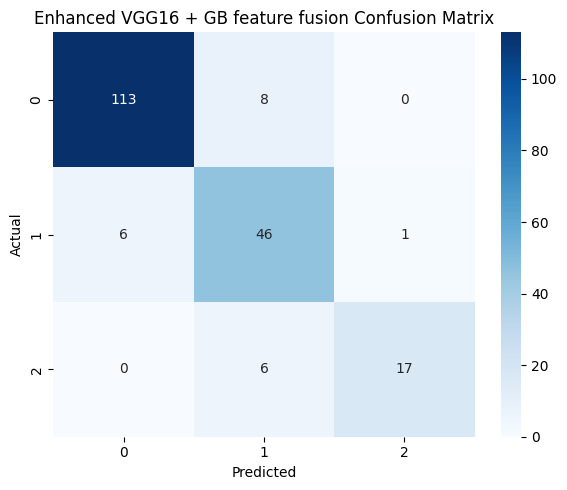


Classification Report Saved successfully!
              precision    recall  f1-score     support
0              0.949580  0.933884  0.941667  121.000000
1              0.766667  0.867925  0.814159   53.000000
2              0.944444  0.739130  0.829268   23.000000
accuracy       0.893401  0.893401  0.893401    0.893401
macro avg      0.886897  0.846980  0.861698  197.000000
weighted avg   0.899770  0.893401  0.894240  197.000000


  0%|          | 0/197 [00:00<?, ?it/s]

Top Global Features:
                     Mean |SHAP|
visual_feature_3590     0.003808
visual_feature_423      0.003011
visual_feature_2138     0.002768
visual_feature_1402     0.002751
visual_feature_3728     0.002720
visual_feature_2345     0.002617
visual_feature_2107     0.002299
visual_feature_3189     0.002166
visual_feature_3853     0.002159
visual_feature_3609     0.001991
visual_feature_511      0.001956
visual_feature_1820     0.001702
visual_feature_1871     0.001697
visual_feature_56       0.001580
visual_feature_2024     0.001566
SHAP summary plot successfully saved to: outputs/plots_shap/enhanced_vgg16_+_gb_feature_fusion_shap_summary.png
Top Global Features:
                  Feature  Mean_Abs_SHAP_Error
3590  visual_feature_3590             0.010780
3728  visual_feature_3728             0.007644
423    visual_feature_423             0.006593
1402  visual_feature_1402             0.006231
1181  visual_feature_1181             0.005854
3853  visual_feature_3853           

,Architecture,Estimator,Accuracy,Precision,Recall,F1
0,vgg16,GB,0.893401,0.89977,0.893401,0.89424


In [ ]:
def tune_hybrid_estimator(X_train, y_train, estimator_type="gb", n_trials=50):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    def objective(trial):
        if estimator_type == "gb":
            model = GradientBoostingClassifier(
                n_estimators=trial.suggest_categorical("n_estimators", [100, 200, 300]),
                learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                max_depth=trial.suggest_int("max_depth", 2, 6),
                min_samples_split=trial.suggest_int("min_samples_split", 10, 30),
                min_samples_leaf=trial.suggest_int("min_samples_leaf", 10, 20),
                max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", 0.1, 0.2]),
                random_state=SEED,
            )
        elif estimator_type == "rf":
            model = RandomForestClassifier(
                n_estimators=trial.suggest_categorical("n_estimators", [200, 300, 500]),
                max_depth=trial.suggest_int("max_depth", 3, 20),
                min_samples_split=trial.suggest_int("min_samples_split", 2, 10),
                min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 5),
                max_features=trial.suggest_categorical("max_features", ["sqrt", "log2"]),
                max_samples=trial.suggest_categorical("max_samples", [0.6, 0.8, 1.0]),
                class_weight="balanced_subsample",
                bootstrap=True,
                n_jobs=-1,
                random_state=SEED,
            )
        else:
            raise ValueError("estimator_type must be 'gb' or 'rf'")

        return cross_val_score(
            model, X_train, y_train, cv=cv, scoring="f1_weighted", n_jobs=-1
        ).mean()

    study = optuna.create_study(direction="maximize")
    if estimator_type == "gb":
        study.optimize(objective, n_trials=int(n_trials*.5), show_progress_bar=True)
    else:
        study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    study.trials_dataframe().to_csv(
        RESULT_DIR / f"enhanced_feature_fusion_{estimator_type}_trials.csv",
        index=False,
    )
    return study.best_params

def run_enhanced_feature_fusion(architecture="vgg16", estimator_type="gb", tune=True):
    train_df, test_df = load_master_splits()
    train_embeddings = extract_embeddings(train_df, architecture, "train")
    test_embeddings = extract_embeddings(test_df, architecture, "test")
    X_tab_train, X_tab_test, y_train, y_test, tab_scaler = prepare_tabular(train_df, test_df)

    # Scale embeddings independently to stop either modality dominating by magnitude.
    embedding_scaler = StandardScaler()
    X_emb_train = embedding_scaler.fit_transform(train_embeddings)
    X_emb_test = embedding_scaler.transform(test_embeddings)

    X_train = np.hstack([X_emb_train, X_tab_train])
    X_test = np.hstack([X_emb_test, X_tab_test])

    # Utilise these optimised hyperparameters to save training time
    # NOTE: UNCOMMENT THIS WHOLE IF-ELSE TREE IF YOU WANT TO PROCEED WITH HYPERPARAMETER OPTIMISATION
    if estimator_type == "rf":
        if architecture == "resnet18":
            params = {'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_samples': 1.0}
        elif architecture == "resnet50":
            params = {'n_estimators': 300, 'max_depth': 14, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_samples': 1.0}
        elif architecture == "vgg16":
            params = {'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_samples': 0.6}
        elif architecture == "vit_b_16":
            params = {'n_estimators': 200, 'max_depth': 9, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_samples': 0.8}
        elif architecture == "swin_t":
            params = {'n_estimators': 300, 'max_depth': 18, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_samples': 0.8}
    else:
        if architecture == "resnet18":
            params = {'n_estimators': 300, 'learning_rate': 0.06198679714955447, 'max_depth': 4, 'min_samples_split': 19, 'min_samples_leaf': 11, 'max_features': 'log2'}
        elif architecture == "resnet50":
            params = {'n_estimators': 300, 'learning_rate': 0.07459791799156032, 'max_depth': 2, 'min_samples_split': 16, 'min_samples_leaf': 13, 'max_features': 'sqrt'}
        elif architecture == "vgg16":
            params = {'n_estimators': 300, 'learning_rate': 0.12184227691563385, 'max_depth': 3, 'min_samples_split': 28, 'min_samples_leaf': 17, 'max_features': 'sqrt'}
        elif architecture == "vit_b_16":
            params = {'n_estimators': 100, 'learning_rate': 0.19653079512514782, 'max_depth': 3, 'min_samples_split': 22, 'min_samples_leaf': 17, 'max_features': 'sqrt'}
        elif architecture == "swin_t":
            params = {'n_estimators': 300, 'learning_rate': 0.010561567192592195, 'max_depth': 5, 'min_samples_split': 29, 'min_samples_leaf': 12, 'max_features': 'log2'}
        else:
            params = tune_hybrid_estimator(X_train, y_train, estimator_type)

    if estimator_type == "gb":
        model = GradientBoostingClassifier(**params, random_state=SEED)
    else:
        model = RandomForestClassifier(
            **params,
            class_weight="balanced_subsample",
            bootstrap=True,
            n_jobs=-1,
            random_state=SEED,
        )

    model.fit(X_train, y_train)
    name = f"Enhanced {architecture.upper()} + {estimator_type.upper()} feature fusion"

    # Generate full feature names for SHAP plots
    num_visual_features = X_emb_test.shape[1]
    visual_feature_names = [f"visual_feature_{i}" for i in range(num_visual_features)]
    full_feature_names = visual_feature_names + list(FEATURES_FOR_SCORING)

    predictions, results = evaluate_and_save(name, model, X_test, y_test, full_feature_names)

    prefix = MODEL_DIR / f"enhanced_{architecture}_{estimator_type}"
    joblib.dump(model, f"{prefix}_model.pkl")
    joblib.dump(tab_scaler, f"{prefix}_tabular_scaler.pkl")
    joblib.dump(embedding_scaler, f"{prefix}_embedding_scaler.pkl")
    joblib.dump(FEATURES_FOR_SCORING, f"{prefix}_tabular_columns.pkl")
    return model, results

# Modified evaluate_and_save to accept full_feature_names
def evaluate_and_save(name, model, X_test, y_test, full_feature_names):
    predictions = model.predict(X_test)
    results = evaluate_model(
        name,
        y_test,
        predictions,
    )

    safe_name = (
        name.lower()
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("/", "_")
    )

    plot_confusion_matrix(
        name,
        y_test,
        predictions,
        PLOT_DIR / f"{safe_name}_cm.png",
    )
    save_classification_report(
        y_test,
        predictions,
        RESULT_DIR / f"{safe_name}_report.csv",
    )

    # Pass the correctly constructed feature names to SHAP functions
    shap_values = generate_global_shap_plots(
        model,
        X_test,
        full_feature_names,
        name
    )

    generate_shap_error_plots(
        model,
        X_test,
        y_test,
        predictions,
        full_feature_names,
        name,
        shap_values
    )

    compare_global_vs_error_shap(
        shap_values,
        X_test,
        y_test,
        predictions,
        full_feature_names,
        f"outputs/results/{name.replace(' ', '_')}_global_vs_error_shap_comparison.csv"
    )

    return predictions, results

summary = []

for estimator in ["rf", "gb"]:
    for architecture in SUPPORTED_ARCHITECTURES:
        log_resource_usage("Before Tuning")

        print(f"Running {architecture} + {estimator}...")

        _, metrics = run_enhanced_feature_fusion(
            architecture=architecture,
            estimator_type=estimator,
            tune=True
        )

        summary.append({
            "Architecture": architecture,
            "Estimator": estimator.upper(),
            "Accuracy": metrics["accuracy"],
            "Precision": metrics["precision"],
            "Recall": metrics["recall"],
            "F1": metrics["f1_score"]
        })

        log_resource_usage("After Tuning")

results_df = pd.DataFrame(summary)

results_df.to_csv(
    RESULT_DIR / "hybrid_architecture_comparison.csv",
    index=False
)

results_df

In [ ]:
!zip -r outputs_hybrid_new_v8.zip outputs/ -x "outputs/models/cnn_*.pth" "outputs/models/swin_t_production_final.pth" "outputs/models/vit_b_16_production_final.pth"

  adding: outputs/ (stored 0%)
  adding: outputs/embeddings/ (stored 0%)
  adding: outputs/embeddings/train_vgg16_ids.npy (deflated 66%)
  adding: outputs/embeddings/test_resnet18_finetuned_embeddings.npy (deflated 13%)
  adding: outputs/embeddings/test_vit_b_16_ids.npy (deflated 56%)
  adding: outputs/embeddings/test_resnet50_finetuned_embeddings.npy (deflated 11%)
  adding: outputs/embeddings/train_vgg16_finetuned_embeddings.npy (deflated 64%)
  adding: outputs/embeddings/train_swin_t_finetuned_embeddings.npy (deflated 7%)
  adding: outputs/embeddings/test_vgg16_finetuned_embeddings.npy (deflated 64%)
  adding: outputs/embeddings/test_resnet18_ids.npy (deflated 56%)
  adding: outputs/embeddings/train_swin_t_ids.npy (deflated 66%)
  adding: outputs/embeddings/train_resnet18_ids.npy (deflated 66%)
  adding: outputs/embeddings/train_resnet18_finetuned_embeddings.npy (deflated 13%)
  adding: outputs/embeddings/train_vit_b_16_ids.npy (deflated 66%)
  adding: outputs/embeddings/train_vit_b

In [ ]:
from google.colab import files
files.download('/content/outputs_hybrid_new_v8.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
SUPPORTED_ARCHITECTURES

('resnet18', 'resnet50', 'vgg16', 'vit_b_16', 'swin_t')